# Appendix D - Noise Injection and Prevalence Shift

This notebook is part of the reproducibility package for the MSc thesis **Probabilistic Machine Learning Models and Decision Optimization for Hepatocellular Carcinoma Diagnosis**.

> Repository note: paths are resolved from either the repository root or the `notebooks/` directory. Generated figures are written under `outputs/`.


# FULL PIPELINE SCRIPT (Unified) + Robustness/Stress Tests
 - Noise injection is implemented as a custom sklearn Transformer INSIDE the numeric pipeline
   (no leakage: noise scale learned only from each training fold via fit()).
 - Prevalence shift is applied ONLY to the test set via positive downsampling, repeated across
   many seeds to quantify variability.
 - Robustness summary uses empirical 2.5–97.5 percentiles across seeds.

In [1]:
from pathlib import Path
# --- Import libraries ---
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.utils.validation import check_is_fitted
from sklearn.utils import check_random_state

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score, brier_score_loss,
    precision_recall_curve
)
from sklearn.calibration import CalibratedClassifierCV
from xgboost import XGBClassifier
# Resolve repository root for reproducible relative paths
REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "data").exists() and (REPO_ROOT.parent / "data").exists():
    REPO_ROOT = REPO_ROOT.parent


In [2]:
# --- Basic settings ---
warnings.filterwarnings("ignore")
RANDOM_STATE = 42

In [3]:
np.random.seed(RANDOM_STATE)

In [4]:
pd.set_option("display.precision", 4)

In [5]:
# --- Output directory for figures ---
out_dir = REPO_ROOT / "outputs" / "robustness"
os.makedirs(out_dir, exist_ok=True)

In [6]:
# --- Config knobs (easy to tune) ---
NOISE_FACTOR = 1.0     # 0.0 (no noise), 0.5 (moderate), 1.0 (strong)
TARGET_PREV = 0.05     # 5% prevalence in shifted test
N_SEEDS = 30           # number of prevalence-shifted resamples

In [7]:
# Load data
TARGET = "liver_cancer"
df = pd.read_csv(REPO_ROOT / "data" / "synthetic_liver_cancer_dataset.csv")

In [8]:
y = df[TARGET].astype(int).values
X = df.drop(columns=[TARGET])

In [9]:
# Identify feature types
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()

In [10]:
# Quick summary
display(pd.DataFrame({
    "numeric_cols_count": [len(num_cols)],
    "categorical_cols_count": [len(cat_cols)],
    "class_0_ratio": [(y == 0).mean()],
    "class_1_ratio": [(y == 1).mean()],
}))

,numeric_cols_count,categorical_cols_count,class_0_ratio,class_1_ratio
0,9,4,0.7822,0.2178


In [11]:
# Custom Noise Transformer (Leakage-safe)

In [12]:
class GaussianNoiseInjection(BaseEstimator, TransformerMixin):
    """
    Injects Gaussian noise into numerical features to simulate measurement error / aleatoric uncertainty.

    Key points:
    - fit(): learns per-feature standard deviation ONLY from the training data it receives
             (i.e. within each CV fold).
    - transform(): adds noise ~ N(0, (std * noise_factor)).
    """
    def __init__(self, noise_factor=1.0, random_state=42):
        self.noise_factor = noise_factor
        self.random_state = random_state

    def fit(self, X, y=None):
        # X is expected to be numeric numpy array (after imputer)
        X = np.asarray(X)
        # ddof=0 for population std; consistent and stable
        self.stds_ = X.std(axis=0, ddof=0)
        return self

    def transform(self, X):
        # Ensure transformer has been fitted
        check_is_fitted(self, "stds_")
        X = np.asarray(X)

        # Create sklearn-style RNG (deterministic for reproducibility)
        rng = check_random_state(self.random_state)

        # Noise scale per feature
        scale = self.stds_ * self.noise_factor

        # Draw noise with same shape as X
        noise = rng.normal(loc=0.0, scale=scale, size=X.shape)
        return X + noise

In [13]:
# Split into DEV / TEST, then TRAIN / VAL

In [14]:
# Step 1: create TEST (20%)
X_dev, X_test, y_dev, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

In [15]:
# Step 2: split DEV into TRAIN (60% total) and VAL (20% total)
X_train, X_val, y_train, y_val = train_test_split(
    X_dev, y_dev, test_size=0.25, stratify=y_dev, random_state=RANDOM_STATE
)

In [16]:
print("TRAIN size:", X_train.shape, "VAL size:", X_val.shape, "TEST size:", X_test.shape)

TRAIN size: (3000, 13) VAL size: (1000, 13) TEST size: (1000, 13)


In [17]:
# Preprocessing pipelines (Numeric + Categorical)

In [18]:
# Numeric pipeline:
# - Impute missing values
# - Add Gaussian noise (robustness / realism)
# - Standardize

In [19]:
numeric_tf = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("noise", GaussianNoiseInjection(noise_factor=NOISE_FACTOR, random_state=RANDOM_STATE)),
    ("scaler", StandardScaler())
])

In [20]:
# Categorical pipeline:
# - Impute missing
# - One-hot encode (ignore unseen categories in validation/test)
categorical_tf = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

In [21]:
# Combine numeric + categorical
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_tf, num_cols),
    ("cat", categorical_tf, cat_cols)
])

In [22]:
# Define models

In [23]:
log_reg = LogisticRegression(
    max_iter=5000,
    class_weight="balanced",
    solver="lbfgs"
)

In [24]:
rf = RandomForestClassifier(
    random_state=RANDOM_STATE,
    n_jobs=-1
)

In [25]:
# XGBoost: scale_pos_weight based on TRAIN only (good practice)
pos_weight = (y_train == 0).sum() / max((y_train == 1).sum(), 1)

In [26]:
xgb = XGBClassifier(
    objective="binary:logistic",
    eval_metric="auc",
    random_state=RANDOM_STATE,
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1.0,
    n_jobs=-1,
    scale_pos_weight=pos_weight
)

In [27]:
# Wrap models into full pipelines (prep + model)

In [28]:
pipe_lr = Pipeline([("prep", preprocessor), ("clf", log_reg)])

In [29]:
pipe_rf = Pipeline([("prep", preprocessor), ("clf", rf)])

In [30]:
pipe_xgb = Pipeline([("prep", preprocessor), ("clf", xgb)])

In [31]:
# Hyper-parameter tuning (GridSearchCV on TRAIN)

In [32]:
param_grid_lr = {"clf__C": [0.1, 1.0, 3.0], "clf__solver": ["lbfgs", "liblinear"]}

In [33]:
param_grid_rf = {"clf__n_estimators": [300, 600], "clf__max_depth": [None, 8]}

In [34]:
param_grid_xgb = {"clf__n_estimators": [300, 600], "clf__max_depth": [3, 5], "clf__learning_rate": [0.03, 0.07]}

In [35]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

In [36]:
def tune(pipe, grid, name):
    """
    Grid search on TRAIN using ROC-AUC.
    NOTE: Because noise is inside the pipeline, it is applied fold-safely:
          - noise scale learned on training fold
          - noise applied to training fold and validation fold during CV evaluation.
    """
    gs = GridSearchCV(
        estimator=pipe,
        param_grid=grid,
        scoring="roc_auc",
        cv=cv,
        n_jobs=-1,
        refit=True,
        verbose=0
    )
    gs.fit(X_train, y_train)
    return (
        {"model": name, "cv_best_roc_auc": gs.best_score_, "best_params": gs.best_params_},
        gs.best_estimator_
    )

In [38]:
res_lr, best_lr = tune(pipe_lr, param_grid_lr, "LogisticRegression")

In [39]:
res_rf, best_rf = tune(pipe_rf, param_grid_rf, "RandomForest")

In [40]:
res_xgb, best_xgb = tune(pipe_xgb, param_grid_xgb, "XGBoost")

In [41]:
tuning_tbl = pd.DataFrame([res_lr, res_rf, res_xgb])

In [42]:
print("\nTuning Results (Training with Noise in Pipeline):")
display(tuning_tbl)


Tuning Results (Training with Noise in Pipeline):


,model,cv_best_roc_auc,best_params
0,LogisticRegression,0.8545,"{'clf__C': 1.0, 'clf__solver': 'lbfgs'}"
1,RandomForest,0.8557,"{'clf__max_depth': 8, 'clf__n_estimators': 600}"
2,XGBoost,0.8572,"{'clf__learning_rate': 0.03, 'clf__max_depth':..."


In [43]:
# Calibration selection on VALIDATION (pick isotonic vs sigmoid by Brier)

In [44]:
cv_cal = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

In [45]:
def pick_calibration(model, X_tr, y_tr, X_va, y_va, cv_cal):
    """
    Chooses calibration method (isotonic vs sigmoid) using Brier score on a held-out validation set.
    - We fit a calibrated model using ONLY X_tr, y_tr.
    - We evaluate Brier on X_va, y_va.
    """
    candidates = {}
    scores = {}

    for m in ["isotonic", "sigmoid"]:
        cal = CalibratedClassifierCV(model, method=m, cv=cv_cal)
        cal.fit(X_tr, y_tr)
        proba_val = cal.predict_proba(X_va)[:, 1]
        scores[m] = brier_score_loss(y_va, proba_val)
        candidates[m] = cal

    best_m = min(scores, key=scores.get)
    return candidates[best_m], best_m, scores

In [46]:
cal_lr, m_lr, s_lr = pick_calibration(best_lr, X_train, y_train, X_val, y_val, cv_cal)

In [47]:
cal_rf, m_rf, s_rf = pick_calibration(best_rf, X_train, y_train, X_val, y_val, cv_cal)

In [48]:
cal_xgb, m_xgb, s_xgb = pick_calibration(best_xgb, X_train, y_train, X_val, y_val, cv_cal)

In [49]:
calibration_tbl = pd.DataFrame([
    {"model": "LogisticRegression", "picked": m_lr, "val_brier": s_lr[m_lr]},
    {"model": "RandomForest", "picked": m_rf, "val_brier": s_rf[m_rf]},
    {"model": "XGBoost", "picked": m_xgb, "val_brier": s_xgb[m_xgb]},
])
display(calibration_tbl)

,model,picked,val_brier
0,LogisticRegression,sigmoid,0.1135
1,RandomForest,isotonic,0.1144
2,XGBoost,sigmoid,0.1133


In [50]:
# Final fit on DEV (TRAIN + VAL), keep TEST untouched

In [51]:
X_dev_final = pd.concat([X_train, X_val], axis=0)
y_dev_final = np.concatenate([y_train, y_val], axis=0)

In [52]:
# Refit the calibrated models on the full DEV

In [53]:
cal_lr.fit(X_dev_final, y_dev_final)

,estimator,Pipeline(step..._iter=5000))])
,method,'sigmoid'
,cv,StratifiedKFo... shuffle=True)
,n_jobs,None
,ensemble,'auto'
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False


In [54]:
cal_rf.fit(X_dev_final, y_dev_final)

,estimator,Pipeline(step...m_state=42))])
,method,'isotonic'
,cv,StratifiedKFo... shuffle=True)
,n_jobs,None
,ensemble,'auto'
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False


In [55]:
cal_xgb.fit(X_dev_final, y_dev_final)

,estimator,"Pipeline(step...=None, ...))])"
,method,'sigmoid'
,cv,StratifiedKFo... shuffle=True)
,n_jobs,None
,ensemble,'auto'
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False


In [56]:
# Robust evaluation loop (Prevalence shift with many seeds)

In [57]:
def adjust_test_prevalence_seeded(X, y, target_prevalence, seed):
    """
    Downsamples positive class to reach target prevalence (fixed-N constraint).
    - Keeps all negatives (0)
    - Randomly subsamples positives (1) to match target prevalence:
        n1_needed / (n0 + n1_needed) = target_prevalence
    Uses local RNG for reproducibility without affecting global state.
    """
    rng = np.random.default_rng(seed)

    y_arr = y if isinstance(y, np.ndarray) else np.asarray(y)
    idx_0 = np.where(y_arr == 0)[0]
    idx_1 = np.where(y_arr == 1)[0]

    n_0 = len(idx_0)
    n_1_needed = int(n_0 * target_prevalence / (1 - target_prevalence))
    n_1_needed = min(n_1_needed, len(idx_1))

    # Ensure both classes exist (roc_auc_score requires both)
    if n_0 < 1 or n_1_needed < 1:
        raise ValueError("Not enough samples to form shifted test set with both classes.")

    idx_1_selected = rng.choice(idx_1, size=n_1_needed, replace=False)
    new_indices = np.concatenate([idx_0, idx_1_selected])

    # Shuffling makes the cohort look like a realistic mixed test set.
    # Note: with deterministic noise in the pipeline, shuffling can change which sample receives
    # which noise draw (because noise is generated per row order). This is OK if you interpret
    # results as "noise + prevalence variability combined".
    rng.shuffle(new_indices)

    return X.iloc[new_indices], y_arr[new_indices]

In [58]:
def robust_evaluate(model, X_test_base, y_test_base, n_seeds=30, target_prev=0.05):
    """
    Runs evaluation multiple times with different downsampling seeds to simulate low prevalence.
    Collects ROC-AUC, AP, and Brier.

    Output summary:
    - mean
    - empirical 95% interval across seeds (2.5th to 97.5th percentiles)
      This is better here than "mean ± 1.96*SE" because each seed produces a different shifted cohort.
    """
    records = []

    for seed in range(n_seeds):
        # 1) Shift prevalence
        X_shifted, y_shifted = adjust_test_prevalence_seeded(
            X_test_base, y_test_base, target_prevalence=target_prev, seed=seed
        )

        # 2) Predict probabilities (noise is applied automatically via pipeline inside the model)
        proba = model.predict_proba(X_shifted)[:, 1]

        # 3) Metrics
        auc = roc_auc_score(y_shifted, proba)
        ap = average_precision_score(y_shifted, proba)
        brier = brier_score_loss(y_shifted, proba)

        records.append({"auc": auc, "ap": ap, "brier": brier})

    df_metrics = pd.DataFrame(records)

    # Summarize with mean + empirical 95% interval
    stats = {}
    for col in df_metrics.columns:
        stats[f"{col}_mean"] = df_metrics[col].mean()
        stats[f"{col}_lo"], stats[f"{col}_hi"] = np.percentile(df_metrics[col], [2.5, 97.5])

    return stats, df_metrics

In [59]:
print(f"\n--- Running Robustness Check ({N_SEEDS} Seeds) ---")
print(f"Conditions: Noise (factor={NOISE_FACTOR} via Pipeline) + Prevalence Shift (Target: {TARGET_PREV:.0%})")


--- Running Robustness Check (30 Seeds) ---
Conditions: Noise (factor=1.0 via Pipeline) + Prevalence Shift (Target: 5%)


In [60]:
results_robust = []
all_metrics = {}

In [61]:
for model_name, model in [("LR", cal_lr), ("RF", cal_rf), ("XGB", cal_xgb)]:
    stats, df_metrics = robust_evaluate(
        model, X_test, y_test, n_seeds=N_SEEDS, target_prev=TARGET_PREV
    )
    all_metrics[model_name] = df_metrics

    row = {"model": model_name}
    row.update(stats)
    results_robust.append(row)

In [62]:
summary_robust = pd.DataFrame(results_robust)

In [63]:
# Nicely formatted display table
summary_display = summary_robust[["model"]].copy()

In [64]:
summary_display["AUC"] = summary_robust.apply(
    lambda x: f"{x['auc_mean']:.4f} [{x['auc_lo']:.4f}, {x['auc_hi']:.4f}]",
    axis=1
)

In [65]:
summary_display["AP"] = summary_robust.apply(
    lambda x: f"{x['ap_mean']:.4f} [{x['ap_lo']:.4f}, {x['ap_hi']:.4f}]",
    axis=1
)

In [66]:
summary_display["Brier"] = summary_robust.apply(
    lambda x: f"{x['brier_mean']:.4f} [{x['brier_lo']:.4f}, {x['brier_hi']:.4f}]",
    axis=1
)

In [67]:
print("\n--- FINAL ROBUST TEST SET RESULTS ---")
display(summary_display)


--- FINAL ROBUST TEST SET RESULTS ---


,model,AUC,AP,Brier
0,LR,"0.8626 [0.8234, 0.8997]","0.3732 [0.2245, 0.4850]","0.0640 [0.0577, 0.0713]"
1,RF,"0.8733 [0.8367, 0.9043]","0.3845 [0.2411, 0.4966]","0.0617 [0.0575, 0.0676]"
2,XGB,"0.8825 [0.8476, 0.9098]","0.4071 [0.2596, 0.4874]","0.0606 [0.0561, 0.0678]"


In [68]:
# PR curve for one example shifted cohort

In [69]:
# We generate a single shifted test set for plotting a representative PR curve.
X_test_plot, y_test_plot = adjust_test_prevalence_seeded(X_test, y_test, TARGET_PREV, seed=RANDOM_STATE)
proba_xgb_plot = cal_xgb.predict_proba(X_test_plot)[:, 1]

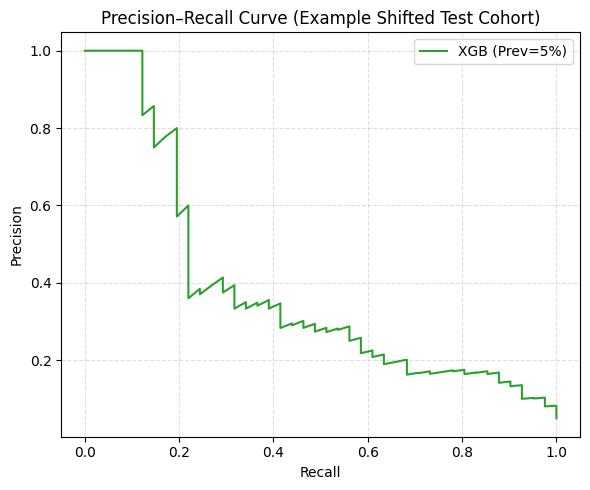

In [72]:
plt.figure(figsize=(6, 5))
prec, rec, _ = precision_recall_curve(y_test_plot, proba_xgb_plot)
plt.plot(rec, prec, label=f"XGB (Prev={TARGET_PREV:.0%})", color="C2")
plt.title("Precision–Recall Curve (Example Shifted Test Cohort)")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()

save_path = os.path.join(out_dir, "robust_pr_curve.png")
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()